In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/dataset_selection.csv")

print("Aperçu du dataset :")
print(df.head())
print(f"\nNombre total d'images : {len(df)}")

class_counts = df['label'].value_counts()
print("\nRépartition des labels :")
print(class_counts)

Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/ORIGA/ORIGA...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome

Nombre total d'images : 6208

Répartition des labels :
label
glaucome    1552
mda         1552
diabete     1552
normaux     1552
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp['label'], random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)} ({len(df_train)/len(df)*100:.0f}%)")
print(f"Val   : {len(df_val)}   ({len(df_val)/len(df)*100:.0f}%)")
print(f"Test  : {len(df_test)}  ({len(df_test)/len(df)*100:.0f}%)")

classes = sorted(df['label'].unique().tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
print(f"\nClasses : {classes}")


Tailles des splits :
Train : 4966 (80%)
Val   : 621   (10%)
Test  : 621  (10%)

Classes : ['diabete', 'glaucome', 'mda', 'normaux']


In [3]:
def crop_black_border(img, thr=10, pad=10):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(img.shape[0] - 1, y1 + pad)
    x1 = min(img.shape[1] - 1, x1 + pad)
    return img[y0:y1+1, x0:x1+1]

def load_image(path, size=(128, 128)):
    img = cv2.imread(path)
    if img is None:
        return None
    img = crop_black_border(img, thr=10, pad=10)
    img = cv2.resize(img, size)
    return img

def augment_image(img):
    aug = []
    for angle in [-15, 15]:
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1)
        aug.append(cv2.warpAffine(img, M, (w, h)))
    aug.append(cv2.flip(img, 1))
    return aug

print("Fonctions de prétraitement définies ✓")

Fonctions de prétraitement définies ✓


In [4]:
from skimage.feature import hog

def extract_hog_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features

def extract_pixel_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.flatten().astype(np.float32) / 255.0

print("Fonctions d'extraction de features définies ✓")
print(f"HOG sur image 128x128 donne {extract_hog_features(np.zeros((128, 128, 3), dtype=np.uint8)).shape[0]} features")
print(f"Pixels aplatis sur image 128x128 donne {128*128} features")


Fonctions d'extraction de features définies ✓
HOG sur image 128x128 donne 8100 features
Pixels aplatis sur image 128x128 donne 16384 features


In [5]:
def extract_all_features(df_subset, extract_func, augment=False):
    features, labels, valid_indices = [], [], []
    for idx, row in tqdm(df_subset.iterrows(), total=len(df_subset)):
        img = load_image(row['path'])
        if img is None:
            continue
        features.append(extract_func(img))
        labels.append(label_to_id[row['label']])
        valid_indices.append(idx)
        if augment:
            for aug_img in augment_image(img):
                features.append(extract_func(aug_img))
                labels.append(label_to_id[row['label']])
                valid_indices.append(idx)
    return np.array(features), np.array(labels), valid_indices

print("Extraction des features pixels...")
X_train_pixels, y_train, _ = extract_all_features(df_train, extract_pixel_features, augment=True)
X_val_pixels,   y_val,   _ = extract_all_features(df_val,   extract_pixel_features)
X_test_pixels,  y_test,  _ = extract_all_features(df_test,  extract_pixel_features)

print(f"\nShape X_train_pixels : {X_train_pixels.shape}")
print(f"Shape X_val_pixels   : {X_val_pixels.shape}")
print(f"Shape X_test_pixels  : {X_test_pixels.shape}")


Extraction des features pixels...


100%|██████████| 621/621 [00:29<00:00, 21.21it/s]


Shape X_train_pixels : (19864, 16384)
Shape X_val_pixels   : (621, 16384)
Shape X_test_pixels  : (621, 16384)


In [6]:
print("Extraction des features HOG...")
X_train_hog, _, _ = extract_all_features(df_train, extract_hog_features, augment=True)
X_val_hog,   _, _ = extract_all_features(df_val,   extract_hog_features)
X_test_hog,  _, _ = extract_all_features(df_test,  extract_hog_features)

print(f"\nShape X_train_hog : {X_train_hog.shape}")
print(f"Shape X_val_hog   : {X_val_hog.shape}")
print(f"Shape X_test_hog  : {X_test_hog.shape}")


Extraction des features HOG...


100%|██████████| 621/621 [00:30<00:00, 20.49it/s]


Shape X_train_hog : (19864, 8100)
Shape X_val_hog   : (621, 8100)
Shape X_test_hog  : (621, 8100)


In [7]:
import gc
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler_pixels = StandardScaler()
X_train_pixels_scaled = scaler_pixels.fit_transform(X_train_pixels)
X_val_pixels_scaled   = scaler_pixels.transform(X_val_pixels)
X_test_pixels_scaled  = scaler_pixels.transform(X_test_pixels)

del X_train_pixels, X_val_pixels, X_test_pixels
gc.collect()
print(f"Shape X_train_pixels_scaled : {X_train_pixels_scaled.shape}")


Shape X_train_pixels_scaled : (19864, 16384)


In [8]:
scaler_hog = StandardScaler()
X_train_hog_scaled = scaler_hog.fit_transform(X_train_hog)
X_val_hog_scaled   = scaler_hog.transform(X_val_hog)
X_test_hog_scaled  = scaler_hog.transform(X_test_hog)

del X_train_hog, X_val_hog, X_test_hog
gc.collect()
print(f"Shape X_train_hog_scaled : {X_train_hog_scaled.shape}")


Shape X_train_hog_scaled : (19864, 8100)


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import random
from itertools import product

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")
if device.type == 'cuda':
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go")

# ── Modèle ──────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layer_sizes, activation='relu', dropout=0.3):
        super().__init__()
        act_cls = nn.ReLU if activation == 'relu' else nn.Tanh
        layers, prev = [], input_dim
        for h in hidden_layer_sizes:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), act_cls(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 4))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# ── Entraînement ─────────────────────────────────────────────────────────────
N_ITER, N_EPOCHS, BATCH, PATIENCE = 50, 200, 256, 10

def to_loader(X, y, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32),
                       torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=BATCH if shuffle else BATCH * 4, shuffle=shuffle)

def train_mlp(X_tr, y_tr, X_val, y_val, params):
    train_loader = to_loader(X_tr,  y_tr,  shuffle=True)
    val_loader   = to_loader(X_val, y_val, shuffle=False)

    model     = MLP(X_tr.shape[1], params['hidden_layer_sizes'],
                    params['activation'], params['dropout']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'], weight_decay=params['alpha'])
    criterion = nn.CrossEntropyLoss()

    best_val_acc, best_state, no_improve = 0.0, None, 0
    loss_curve = []

    for _ in range(N_EPOCHS):
        model.train()
        epoch_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(Xb)
        loss_curve.append(epoch_loss / len(X_tr))

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                correct += (model(Xb).argmax(1) == yb).sum().item()
                total   += len(yb)
        val_acc = correct / total

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                break

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, best_val_acc, loss_curve

def predict(model, X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32)), batch_size=512)
    preds  = []
    with torch.no_grad():
        for (Xb,) in loader:
            preds.append(model(Xb.to(device)).argmax(1).cpu())
    return torch.cat(preds).numpy()

# ── Hyperparamètres ──────────────────────────────────────────────────────────
mlp_params = {
    'hidden_layer_sizes': [(256,), (512,), (256, 128), (512, 256), (512, 256, 128)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [1e-4, 1e-3, 1e-2],
    'lr':                 [1e-3, 5e-4, 1e-4],
    'dropout':            [0.0, 0.2, 0.4],
}
pca_components = [30, 50, 75, 100, 125, 150]

print("\nParamètres MLP à tester :")
for k, v in mlp_params.items():
    print(f"  {k}: {v}")
print(f"\nComposantes PCA à tester : {pca_components}")


Device utilisé : cuda
GPU : NVIDIA GeForce RTX 3070 Ti
VRAM disponible : 8.6 Go

Paramètres MLP à tester :
  hidden_layer_sizes: [(256,), (512,), (256, 128), (512, 256), (512, 256, 128)]
  activation: ['relu', 'tanh']
  alpha: [0.0001, 0.001, 0.01]
  lr: [0.001, 0.0005, 0.0001]
  dropout: [0.0, 0.2, 0.4]

Composantes PCA à tester : [30, 50, 75, 100, 125, 150]


In [10]:
from sklearn.decomposition import PCA as skPCA

print("=" * 60)
print("Random search pour : PCA")
print("=" * 60)

all_keys = ['pca_n'] + list(mlp_params.keys())
all_vals = [pca_components] + list(mlp_params.values())
combos   = list(product(*all_vals))
sample   = random.Random(42).sample(combos, min(N_ITER, len(combos)))

results = {}
best_score_pca, best_params_pca, best_model_pca, best_pca_obj = -1, None, None, None

for combo in tqdm(sample, desc="PCA"):
    params = dict(zip(all_keys, combo))
    pca_n  = params.pop('pca_n')
    pca_obj   = skPCA(n_components=pca_n, random_state=42).fit(X_train_pixels_scaled)
    X_tr_pca  = pca_obj.transform(X_train_pixels_scaled)
    X_val_pca = pca_obj.transform(X_val_pixels_scaled)
    model, val_acc, _ = train_mlp(X_tr_pca, y_train, X_val_pca, y_val, params)
    del X_tr_pca, X_val_pca
    if val_acc > best_score_pca:
        best_score_pca  = val_acc
        best_params_pca = {**params, 'pca_n': pca_n}
        best_model_pca  = model
        best_pca_obj    = pca_obj

gc.collect()
best_X_test_pca = best_pca_obj.transform(X_test_pixels_scaled)

print(f"\nMeilleurs paramètres : {best_params_pca}")
print(f"Meilleur score val   : {best_score_pca:.4f}")

results['PCA'] = {
    'best_model':    best_model_pca,
    'best_params':   best_params_pca,
    'best_cv_score': best_score_pca,
    'X_test':        best_X_test_pca,
}


Random search pour : PCA


PCA: 100%|██████████| 50/50 [16:15<00:00, 19.51s/it]


Meilleurs paramètres : {'hidden_layer_sizes': (512, 256, 128), 'activation': 'relu', 'alpha': 0.01, 'lr': 0.0005, 'dropout': 0.2, 'pca_n': 75}
Meilleur score val   : 0.8245


In [11]:
print("=" * 60)
print("Random search pour : HOG")
print("=" * 60)

keys_hog   = list(mlp_params.keys())
combos_hog = list(product(*mlp_params.values()))
sample_hog = random.Random(42).sample(combos_hog, min(N_ITER, len(combos_hog)))

best_score_hog, best_params_hog, best_model_hog = -1, None, None

for combo in tqdm(sample_hog, desc="HOG"):
    params = dict(zip(keys_hog, combo))
    model, val_acc, _ = train_mlp(X_train_hog_scaled, y_train,
                                  X_val_hog_scaled,   y_val, params)
    if val_acc > best_score_hog:
        best_score_hog  = val_acc
        best_params_hog = params
        best_model_hog  = model

print(f"\nMeilleurs paramètres : {best_params_hog}")
print(f"Meilleur score val   : {best_score_hog:.4f}")

results['HOG'] = {
    'best_model':    best_model_hog,
    'best_params':   best_params_hog,
    'best_cv_score': best_score_hog,
    'X_test':        X_test_hog_scaled,
}


Random search pour : HOG


HOG: 100%|██████████| 50/50 [06:08<00:00,  7.38s/it]


Meilleurs paramètres : {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 0.0001, 'lr': 0.001, 'dropout': 0.0}
Meilleur score val   : 0.8116


In [12]:
print("=" * 60)
print("Random search pour : PCA + HOG")
print("=" * 60)

all_keys_c = ['pca_n'] + list(mlp_params.keys())
all_vals_c = [pca_components] + list(mlp_params.values())
combos_c   = list(product(*all_vals_c))
sample_c   = random.Random(42).sample(combos_c, min(N_ITER, len(combos_c)))

best_score_c, best_params_c, best_model_c, best_pca_obj_c = -1, None, None, None

for combo in tqdm(sample_c, desc="PCA+HOG"):
    params = dict(zip(all_keys_c, combo))
    pca_n  = params.pop('pca_n')
    pca_obj   = skPCA(n_components=pca_n, random_state=42).fit(X_train_pixels_scaled)
    X_tr_c  = np.hstack([pca_obj.transform(X_train_pixels_scaled), X_train_hog_scaled])
    X_val_c = np.hstack([pca_obj.transform(X_val_pixels_scaled),   X_val_hog_scaled])
    model, val_acc, _ = train_mlp(X_tr_c, y_train, X_val_c, y_val, params)
    del X_tr_c, X_val_c
    if val_acc > best_score_c:
        best_score_c   = val_acc
        best_params_c  = {**params, 'pca_n': pca_n}
        best_model_c   = model
        best_pca_obj_c = pca_obj

gc.collect()
best_X_test_c = np.hstack([best_pca_obj_c.transform(X_test_pixels_scaled), X_test_hog_scaled])

print(f"\nMeilleurs paramètres : {best_params_c}")
print(f"Meilleur score val   : {best_score_c:.4f}")

results['PCA + HOG'] = {
    'best_model':    best_model_c,
    'best_params':   best_params_c,
    'best_cv_score': best_score_c,
    'X_test':        best_X_test_c,
}


Random search pour : PCA + HOG


PCA+HOG: 100%|██████████| 50/50 [11:14<00:00, 13.49s/it]


Meilleurs paramètres : {'hidden_layer_sizes': (512, 256, 128), 'activation': 'relu', 'alpha': 0.0001, 'lr': 0.0001, 'dropout': 0.4, 'pca_n': 100}
Meilleur score val   : 0.8180


In [13]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

print("\n" + "="*70)
print("ÉVALUATION SUR LE JEU DE TEST")
print("="*70)

comparison_data = []

for name, data in results.items():
    y_pred = predict(data['best_model'], data['X_test'])

    acc  = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred,    average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred,        average='macro', zero_division=0)

    results[name]['test_accuracy'] = acc
    results[name]['test_f1']       = f1
    results[name]['y_pred']        = y_pred

    comparison_data.append({
        'Approche':      name,
        'Val Score':     data['best_cv_score'],
        'Test Accuracy': acc,
        'Balanced Acc':  bacc,
        'Precision':     prec,
        'Recall':        rec,
        'F1 Score':      f1,
    })

    print(f"\n--- {name} ---")
    print(f"Meilleurs paramètres : {data['best_params']}")
    print(f"Test Accuracy        : {acc:.4f}")
    print(f"Balanced Accuracy    : {bacc:.4f}")
    print(f"F1 Score (macro)     : {f1:.4f}")

comparison_df = pd.DataFrame(comparison_data).round(4)

print("\n" + "="*70)
print("TABLEAU COMPARATIF DES 3 APPROCHES")
print("="*70)
print(comparison_df.to_string(index=False))

best_approach = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Approche']
print(f"\n✅ Meilleure approche : {best_approach}")



ÉVALUATION SUR LE JEU DE TEST

--- PCA ---
Meilleurs paramètres : {'hidden_layer_sizes': (512, 256, 128), 'activation': 'relu', 'alpha': 0.01, 'lr': 0.0005, 'dropout': 0.2, 'pca_n': 75}
Test Accuracy        : 0.7810
Balanced Accuracy    : 0.7808
F1 Score (macro)     : 0.7703

--- HOG ---
Meilleurs paramètres : {'hidden_layer_sizes': (256, 128), 'activation': 'relu', 'alpha': 0.0001, 'lr': 0.001, 'dropout': 0.0}
Test Accuracy        : 0.7601
Balanced Accuracy    : 0.7599
F1 Score (macro)     : 0.7447

--- PCA + HOG ---
Meilleurs paramètres : {'hidden_layer_sizes': (512, 256, 128), 'activation': 'relu', 'alpha': 0.0001, 'lr': 0.0001, 'dropout': 0.4, 'pca_n': 100}
Test Accuracy        : 0.7874
Balanced Accuracy    : 0.7873
F1 Score (macro)     : 0.7737

TABLEAU COMPARATIF DES 3 APPROCHES
 Approche  Val Score  Test Accuracy  Balanced Acc  Precision  Recall  F1 Score
      PCA     0.8245         0.7810        0.7808     0.7701  0.7808    0.7703
      HOG     0.8116         0.7601        0.

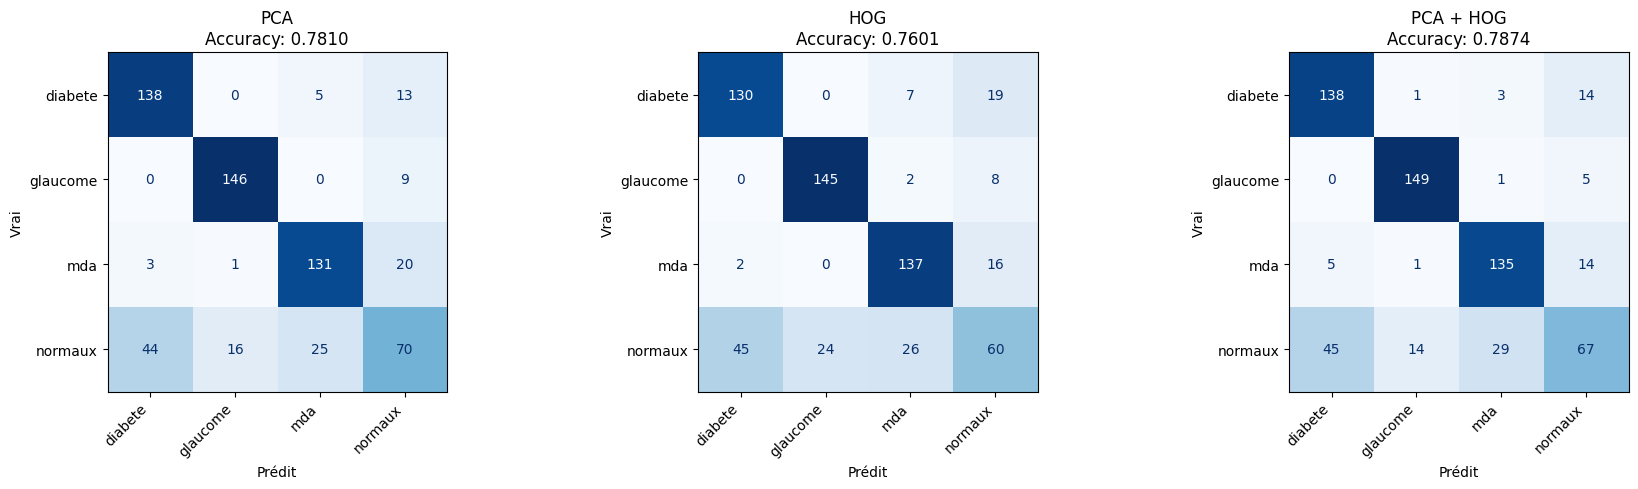

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, data['y_pred'], labels=list(range(len(classes))))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
        ax=axes[idx], values_format='d', cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {data["test_accuracy"]:.4f}')
    axes[idx].set_xlabel('Prédit')
    axes[idx].set_ylabel('Vrai')
    plt.setp(axes[idx].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [15]:
print("\n" + "="*70)
print(f"RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE : {best_approach}")
print("="*70)

best_data = results[best_approach]
print("\nMeilleurs paramètres trouvés :")
for param, value in best_data['best_params'].items():
    print(f"  {param}: {value}")

print("\nRapport de classification :")
print(classification_report(y_test, best_data['y_pred'], target_names=classes, zero_division=0))


RAPPORT DÉTAILLÉ POUR LA MEILLEURE APPROCHE : PCA + HOG

Meilleurs paramètres trouvés :
  hidden_layer_sizes: (512, 256, 128)
  activation: relu
  alpha: 0.0001
  lr: 0.0001
  dropout: 0.4
  pca_n: 100

Rapport de classification :
              precision    recall  f1-score   support

     diabete       0.73      0.88      0.80       156
    glaucome       0.90      0.96      0.93       155
         mda       0.80      0.87      0.84       155
     normaux       0.67      0.43      0.53       155

    accuracy                           0.79       621
   macro avg       0.78      0.79      0.77       621
weighted avg       0.78      0.79      0.77       621



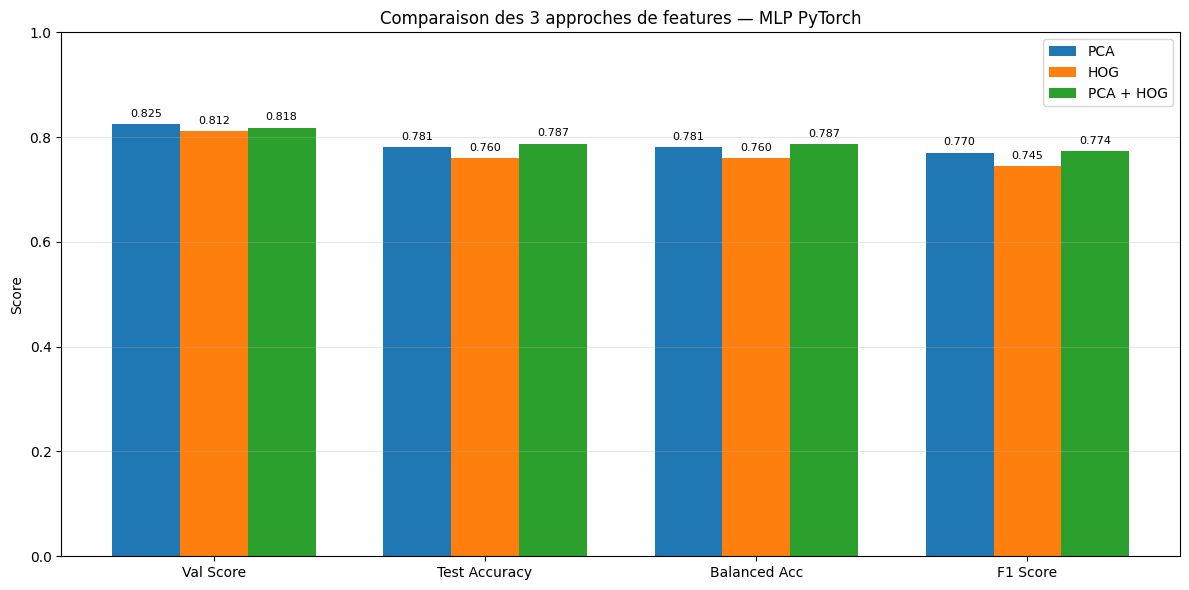

In [16]:
metrics = ['Val Score', 'Test Accuracy', 'Balanced Acc', 'F1 Score']
x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, approach in enumerate(['PCA', 'HOG', 'PCA + HOG']):
    row    = comparison_df[comparison_df['Approche'] == approach].iloc[0]
    values = [row['Val Score'], row['Test Accuracy'], row['Balanced Acc'], row['F1 Score']]
    ax.bar(x + i * width, values, width, label=approach)
    for j, v in enumerate(values):
        ax.text(x[j] + i * width, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score')
ax.set_title('Comparaison des 3 approches de features — MLP PyTorch')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


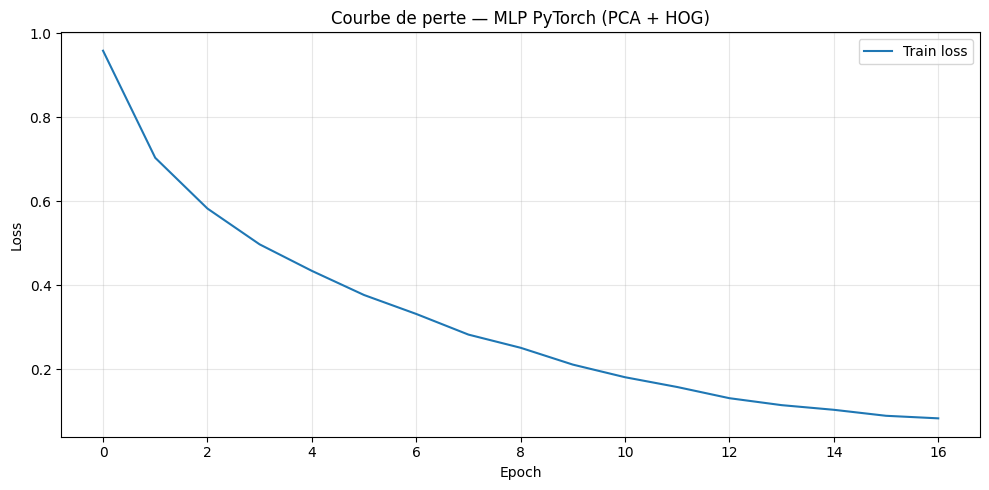

Nombre d'epochs effectuées : 17
Test accuracy : 0.7874


In [17]:
best_data = results[best_approach]
best_p    = best_data['best_params'].copy()

if best_approach == 'PCA':
    pca_n   = best_p.pop('pca_n')
    pca_obj = skPCA(n_components=pca_n, random_state=42).fit(X_train_pixels_scaled)
    X_tr_fin  = pca_obj.transform(X_train_pixels_scaled)
    X_val_fin = pca_obj.transform(X_val_pixels_scaled)
    X_te_fin  = pca_obj.transform(X_test_pixels_scaled)
elif best_approach == 'HOG':
    best_p.pop('pca_n', None)
    X_tr_fin, X_val_fin, X_te_fin = X_train_hog_scaled, X_val_hog_scaled, X_test_hog_scaled
else:
    pca_n   = best_p.pop('pca_n')
    pca_obj = skPCA(n_components=pca_n, random_state=42).fit(X_train_pixels_scaled)
    X_tr_fin  = np.hstack([pca_obj.transform(X_train_pixels_scaled), X_train_hog_scaled])
    X_val_fin = np.hstack([pca_obj.transform(X_val_pixels_scaled),   X_val_hog_scaled])
    X_te_fin  = np.hstack([pca_obj.transform(X_test_pixels_scaled),  X_test_hog_scaled])

_, _, loss_curve = train_mlp(X_tr_fin, y_train, X_val_fin, y_val, best_p)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(loss_curve, label='Train loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'Courbe de perte — MLP PyTorch ({best_approach})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Nombre d'epochs effectuées : {len(loss_curve)}")
print(f"Test accuracy : {accuracy_score(y_test, predict(best_data['best_model'], X_te_fin)):.4f}")
